<a href="https://colab.research.google.com/github/mdmasoomcse/TNS-prcatice-sessions/blob/main/Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Learning Algorithms with Examples

Unsupervised learning is a type of machine learning that looks for previously undetected patterns in a dataset with no pre-existing labels and with a minimum of human supervision. It's often used for tasks like clustering, dimensionality reduction, and anomaly detection. Let's explore some common unsupervised learning algorithms.

## 1. K-Means Clustering

K-Means is a popular algorithm for partitioning `n` observations into `k` clusters where each observation belongs to the cluster with the nearest mean (centroid), serving as a prototype of the cluster. This results in a partitioning of the data space into Voronoi cells.

**Problem Example**: Grouping similar customer segments based on purchasing behavior.

/tmp/ipykernel_792/3296030113.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')


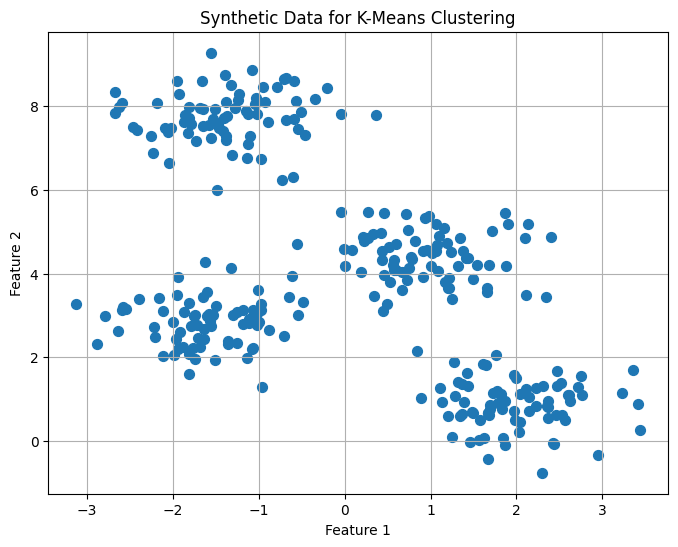

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate synthetic data for K-Means
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Visualize the raw data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')
plt.title('Synthetic Data for K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

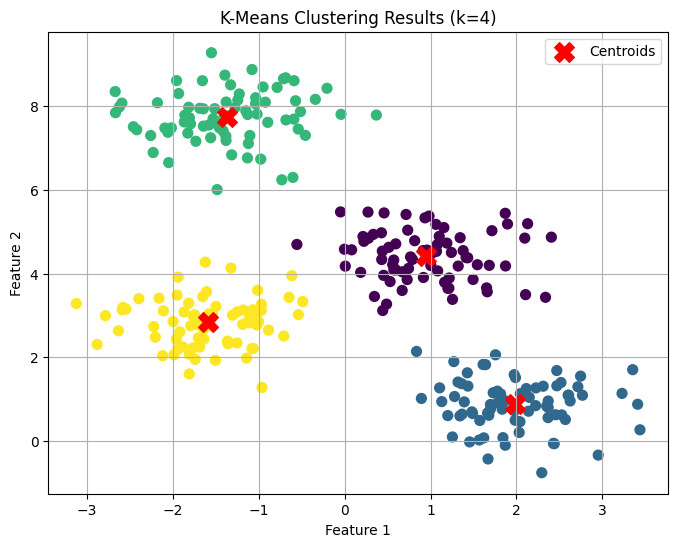

In [2]:
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, random_state=0, n_init=10)
pred_y = kmeans.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=pred_y, s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, marker='X', c='red', label='Centroids')
plt.title('K-Means Clustering Results (k=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## 2. Hierarchical Clustering

Hierarchical clustering builds a hierarchy of clusters. It can be agglomerative (bottom-up, starting with individual data points as clusters and merging them) or divisive (top-down, starting with one cluster and splitting it). A common visualization for hierarchical clustering is a dendrogram.

**Problem Example**: Creating a taxonomy of biological species based on genetic similarities.

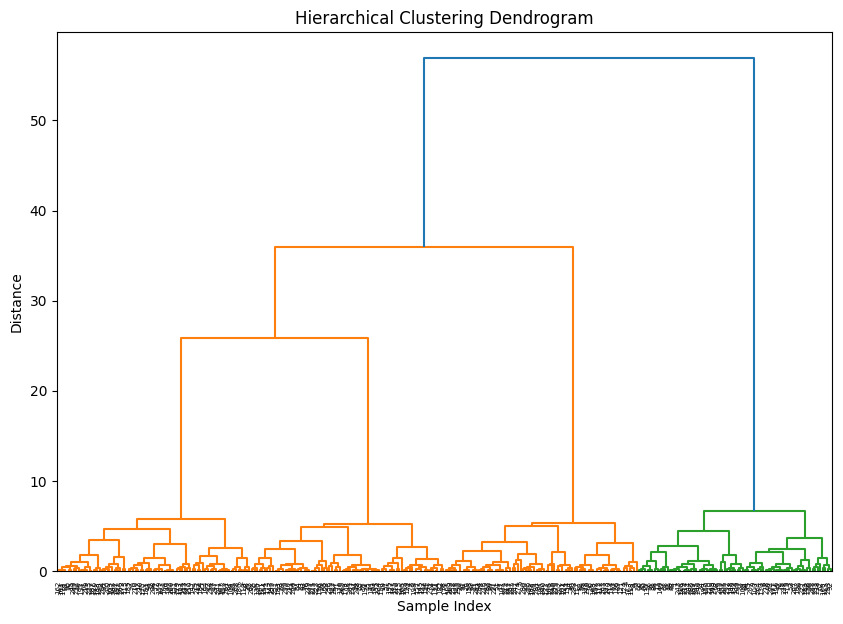

In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# We'll use the same synthetic data (X) from the K-Means example

# Perform hierarchical clustering
linked = linkage(X, method='ward') # 'ward' minimizes the variance within each cluster

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

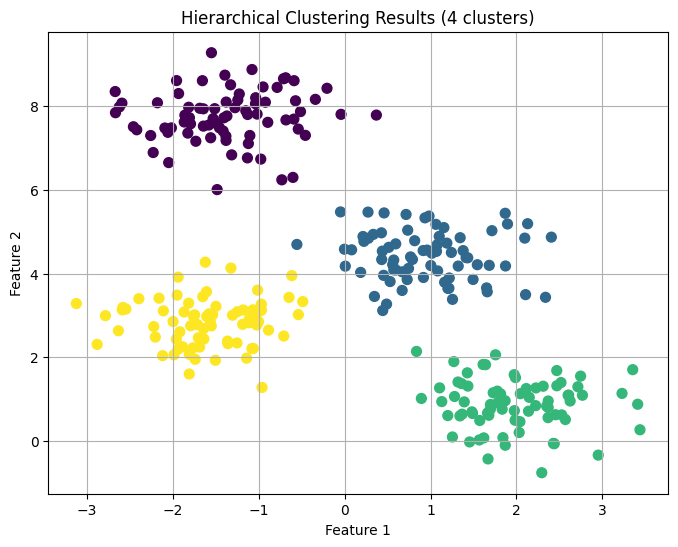

In [4]:
# Apply Agglomerative Clustering (similar to hierarchical clustering, for getting cluster labels)
agg_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_labels = agg_clustering.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=agg_labels, s=50, cmap='viridis')
plt.title('Hierarchical Clustering Results (4 clusters)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

## 3. Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique. It transforms a high-dimensional dataset into a lower-dimensional one while retaining most of the important information. It does this by identifying the principal components, which are orthogonal directions of maximum variance in the data.

**Problem Example**: Reducing the number of features in a dataset to make it easier to visualize or to speed up other machine learning algorithms, such as analyzing gene expression data.

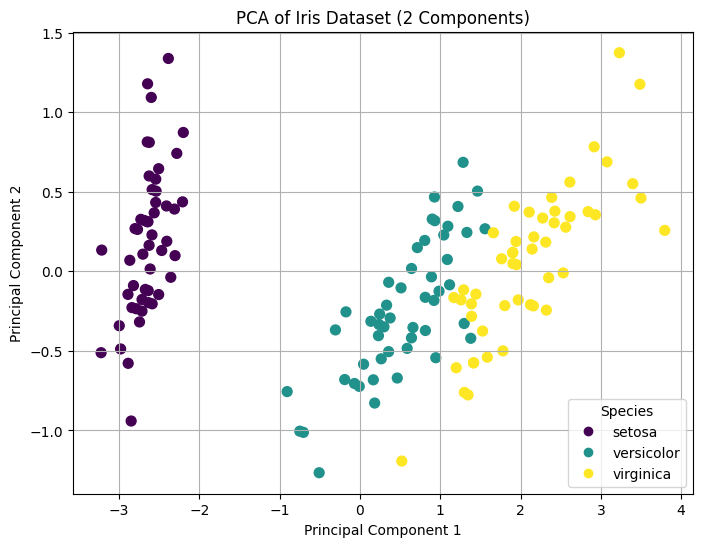

Original number of features: 4
Reduced number of features: 2
Explained variance ratio by each component: [0.92461872 0.05306648]
Total explained variance: 0.98


In [6]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Load the Iris dataset (a classic dataset for PCA demonstration)
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

# Visualize the reduced dimensions
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_iris, cmap='viridis', s=50)
plt.title('PCA of Iris Dataset (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names), title='Species') # Fix: convert target_names to a list
plt.grid(True)
plt.show()

print(f"Original number of features: {X_iris.shape[1]}")
print(f"Reduced number of features: {X_pca.shape[1]}")
print(f"Explained variance ratio by each component: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2f}")